import

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

Final Performance Table

In [ ]:
final_test_results = []

for name, model in final_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        target_names=["Dropout", "Enrolled", "Graduate"],
        output_dict=True,
        zero_division=0
    )

    final_test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 Macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Dropout F1": report["Dropout"]["f1-score"],
        "Enrolled F1": report["Enrolled"]["f1-score"],
        "Graduate F1": report["Graduate"]["f1-score"],
    })

final_perf_df = pd.DataFrame(final_test_results).round(4)

metric_cols = [
    "Accuracy", "Precision (macro)", "Recall (macro)", "F1 Macro",
    "Dropout F1", "Enrolled F1", "Graduate F1"
]

styled_final_perf_df = (
    final_perf_df.style
    .highlight_max(subset=metric_cols, color="#d9ead3")   
    .highlight_min(subset=metric_cols, color="#f4cccc")   
)

display(styled_final_perf_df)

,Model,Accuracy,Precision (macro),Recall (macro),F1 Macro,Dropout F1,Enrolled F1,Graduate F1
0,Logistic Regression (tuned),0.769500,0.709100,0.677500,0.684900,0.780000,0.413800,0.861100
1,Decision Tree,0.694900,0.635700,0.637700,0.636500,0.697300,0.412100,0.800000
2,Random Forest,0.763800,0.715000,0.674300,0.684700,0.774500,0.432400,0.847000
3,SVM RBF (tuned),0.748000,0.690200,0.667100,0.674700,0.760500,0.427000,0.836500
4,XGBoost,0.769500,0.718400,0.705900,0.711100,0.775100,0.503300,0.855000


Overall Comparison Chart

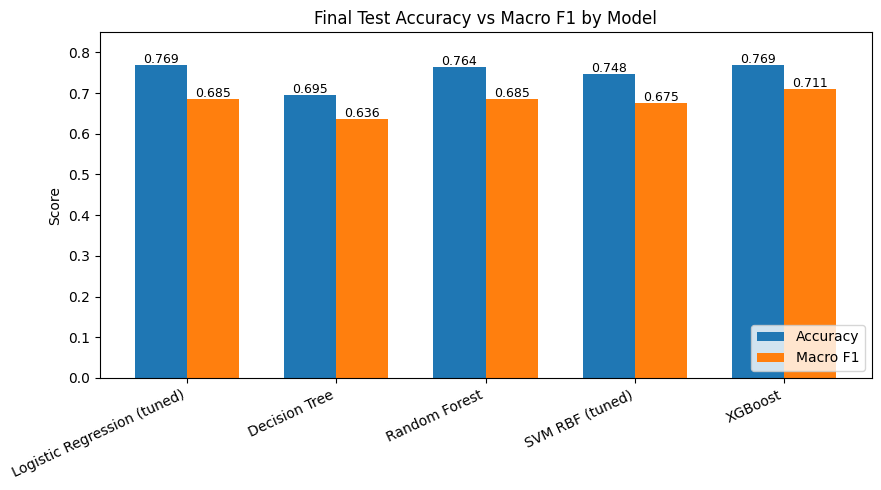

In [32]:

plot_df = final_perf_df[["Model", "Accuracy", "F1 Macro"]].copy()

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, plot_df["Accuracy"], width, label="Accuracy")
plt.bar(x + width/2, plot_df["F1 Macro"], width, label="Macro F1")

plt.xticks(x, plot_df["Model"], rotation=25, ha="right")
plt.ylabel("Score")
plt.title("Final Test Accuracy vs Macro F1 by Model")
plt.ylim(0, max(plot_df["Accuracy"].max(), plot_df["F1 Macro"].max()) + 0.08)
plt.legend(loc="lower right")

for i, v in enumerate(plot_df["Accuracy"]):
    plt.text(i - width/2, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

for i, v in enumerate(plot_df["F1 Macro"]):
    plt.text(i + width/2, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

Class Imbalance Follow-up Analysis

In [33]:
final_models_balanced = {
    "Logistic Regression (tuned, balanced)": LogisticRegression(
        C=lr_grid.best_params_["C"],
        penalty=lr_grid.best_params_["penalty"],
        solver=lr_grid.best_params_["solver"],
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest (balanced)": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ),
}

In [ ]:
balanced_results = []

for name, model in final_models_balanced.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        target_names=["Dropout", "Enrolled", "Graduate"],
        output_dict=True,
        zero_division=0
    )

    balanced_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 Macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Dropout F1": report["Dropout"]["f1-score"],
        "Enrolled F1": report["Enrolled"]["f1-score"],
        "Graduate F1": report["Graduate"]["f1-score"],
    })

balanced_df = pd.DataFrame(balanced_results).round(4)
display(balanced_df)

,Model,Accuracy,Precision (macro),Recall (macro),F1 Macro,Dropout F1,Enrolled F1,Graduate F1
0,"Logistic Regression (tuned, balanced)",0.7299,0.7051,0.7063,0.6942,0.7597,0.5012,0.8217
1,Random Forest (balanced),0.7774,0.7316,0.6838,0.6955,0.7853,0.4392,0.8619
